<h3><b>Name Entity Recognization on Bengali Language</b></h3>



In [ ]:
# What is NER?
'''
# NER = Named Entity Recognition — a sequence-labelling task, where every token in a sentence gets an entity label.
# Example sentence (Bengali transliterated):
#   "Dhaka is the capital of Bangladesh"
#   Dhaka      -> B-LOC   (Beginning of Location)
#   is         -> O       (Outside any entity)
#   the        -> O
#   capital    -> O
#   of         -> O
#   Bangladesh -> B-LOC

# Why BERT?
# BERT (Bidirectional Encoder Representations from Transformers) is a pretrained language model. Instead of training from scratch,
  I FINE-TUNE it — adapting its knowledge to our Bengali NER task.
# This saves time, data, and compute while achieving high accuracy.
'''

In [ ]:
'''
Fine-tuning typically needs only a few thousand examples instead of millions.
BERT reads text in both directions simultaneously, capturing context better than older RNNs
'''

## BIO NER Tagging Format
- BIO tagging scheme: B-TAG = beginning of entity, I-TAG = inside entity, O = no entity. Every single word (token) gets labelled.

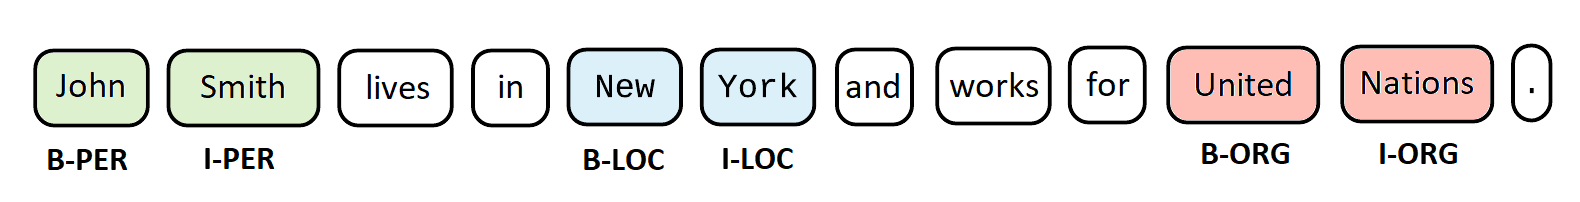
- IOB Tagging:

- Tagging Format Article:
    - https://en.wikipedia.org/wiki/Inside%E2%80%93outside%E2%80%93beginning_(tagging)

In [ ]:
!pip install -U tokenizers
!pip install -U transformers
!pip install -U accelerate
!pip install -U datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("wikiann", "bn")

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

### Load Data

In [ ]:
import pandas as pd

'''
tokens → words
ner_tags → entity labels
spans → entity positions'''

pd.DataFrame(dataset['train'][:])[['tokens', 'ner_tags', 'spans']].iloc[0]

tokens         [ড্যানভিল, ,, ইলিনয়]
ner_tags                   [5, 6, 6]
spans       [LOC: ড্যানভিল , ইলিনয়]
Name: 0, dtype: object

In [ ]:
dataset['train'].features #Shows structure of dataset columns and label definitions.

{'tokens': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'ner_tags': Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None),
 'langs': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None),
 'spans': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)}

Create Label Dictionaries
These dictionaries help convert between machine language and human language.

In [ ]:
tags = dataset['train'].features['ner_tags'].feature
#The dataset stores labels as numbers:
# But humans understand this.

index2tag = {idx:tag for idx, tag in enumerate(tags.names)}
tag2index = {tag:idx for idx, tag in enumerate(tags.names)}

In [ ]:
tags

ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None)

In [ ]:
index2tag

{0: 'O',
 1: 'B-PER',
 2: 'I-PER',
 3: 'B-ORG',
 4: 'I-ORG',
 5: 'B-LOC',
 6: 'I-LOC'}

In [ ]:
tag2index

{'O': 0,
 'B-PER': 1,
 'I-PER': 2,
 'B-ORG': 3,
 'I-ORG': 4,
 'B-LOC': 5,
 'I-LOC': 6}

Add Readable Labels

Now humans can easily inspect examples.
This step is mainly for debugging and understanding.

In [ ]:
def create_tag_names(batch):
  tag_name = {'ner_tags_str': [tags.int2str(idx) for idx in batch['ner_tags']]}
  return tag_name

In [ ]:
dataset = dataset.map(create_tag_names)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
pd.DataFrame(dataset['train'][:])[['tokens', 'ner_tags', 'ner_tags_str']].iloc[0]

tokens          [ড্যানভিল, ,, ইলিনয়]
ner_tags                    [5, 6, 6]
ner_tags_str    [B-LOC, I-LOC, I-LOC]
Name: 0, dtype: object

### Model Downloading
Tokenize dataset and adjust the labels

1. Encode method returns the required keys (input_ids, token_type_ids, attention_mask) but its not a Pytorch/hf dataset

2. Map allows adding new keys to existing splits of the hf dataset, so that's why map is used, no need to make a new dataset from the output of encode adjustment of labels needed as token like "himel" will be split into "him" and "##el" but label for it would still be "B-PER", to align it "him" will get label "B-PER" and ##el gets label "B-PER"

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint, num_labels=7)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

In [ ]:
tokenizer.is_fast

True

In [ ]:
inputs = dataset['train'][0]['tokens']
inputs = tokenizer(inputs, is_split_into_words=True)
inputs.tokens()

['[CLS]',
 'ড',
 '##্যান',
 '##ভি',
 '##ল',
 ',',
 'ই',
 '##লি',
 '##ন',
 '##য়',
 '[SEP]']

In [ ]:
dataset['train'][0]['tokens']

['ড্যানভিল', ',', 'ইলিনয়']

In [ ]:
print(dataset['train'][0]['tokens'])
print(dataset['train'][0]['ner_tags_str'])

['ড্যানভিল', ',', 'ইলিনয়']
['B-LOC', 'I-LOC', 'I-LOC']


In [ ]:
inputs.word_ids()

[None, 0, 0, 0, 0, 1, 2, 2, 2, 2, None]

align_labels_with_tokens() solves the problem that one word can become multiple BERT tokens.

tokenize_and_align_labels() applies that solution to every sentence in the entire dataset so BERT can be trained correctly.

In [ ]:
def align_labels_with_tokens(labels, word_ids):

  """
    Aligns labels with corresponding word tokens based on word_ids.

    Args:
        labels (list): List of labels corresponding to each word token.
        word_ids (list): List of word IDs indicating the tokenization of the input sequence.

    Returns:
        list: New list of labels aligned with word tokens based on word_ids.
              If a token is None, the corresponding label is set to -100.
              If a token is repeated and has an odd label, the label is incremented by 1.

    Example:
        labels = [0, 1, 2, 3, 4]
        word_ids = [0, 1, 1, None, 2]
        new_labels = align_labels_with_tokens(labels, word_ids)
        # Output: [-100, 0, 1, -100, 2]
    """

  new_labels = []
  current_word=None
  for word_id in word_ids:
    if word_id != current_word:
      current_word = word_id
      label = -100 if word_id is None else labels[word_id]
      new_labels.append(label)

    elif word_id is None:
      new_labels.append(-100)

    else:
      label = labels[word_id]

      if label%2==1:
        label = label + 1
      new_labels.append(label)

  return new_labels


In [ ]:
labels = dataset['train'][0]['ner_tags']

word_ids = inputs.word_ids()
print(labels, word_ids)

[5, 6, 6] [None, 0, 0, 0, 0, 1, 2, 2, 2, 2, None]


In [ ]:
align_labels_with_tokens(labels, word_ids)

[-100, 5, 6, 6, 6, 6, 6, 6, 6, 6, -100]

In [ ]:
def tokenize_and_align_labels(examples):

      """
    Tokenizes input examples and aligns the labels with the tokenized inputs.

    Args:
        examples (dict): Dictionary containing input tokens and corresponding NER tags.

    Returns:
        dict: Tokenized inputs with aligned labels.

    Example:
        examples = {'tokens': ["I", "like", "apples", "."], 'ner_tags': [[0, 0, 1, 0]]}
        tokenized_inputs = tokenize_and_align_labels(examples)
        # Output: {'input_ids': [101, 1045, 2066, 11364, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1], 'labels': [[0, 0, 1, 0, -100]]}
    """
  tokenized_inputs = tokenizer(examples['tokens'], truncation=True, is_split_into_words=True)

  all_labels = examples['ner_tags']

  new_labels = []
  for i, labels in enumerate(all_labels):
    word_ids = tokenized_inputs.word_ids(i)
    new_labels.append(align_labels_with_tokens(labels, word_ids))

  tokenized_inputs['labels'] = new_labels

  return tokenized_inputs

In [ ]:
tokenized_datasets = dataset.map(tokenize_and_align_labels, batched=True, remove_columns=dataset['train'].column_names)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets

DatasetDict({
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1000
    })
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 10000
    })
})

### Data Collation and Metrics
Pad the samples per split

1. Each token list per sample will be split
2. Sample x and sample y may not have same length so padding is needed,
this will be used by Trainer API, this is the collate_fn equivalent from pytorch


In [ ]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [ ]:
batch = data_collator([tokenized_datasets['train'][i] for i in range(2)])
batch

{'input_ids': tensor([[   101,    960, 110742,  80045,  13458,    117,    939,  55384,  11737,
          13228,    102,      0,      0,      0,      0,      0,      0,      0,
              0],
        [   101,    976,  27268,  82825,  58354,  74282,  11737,    976,  27268,
          82825,  58354,  74282,  11737,    112,    112,    113,  31633,    114,
            102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]), 'labels': tensor([[-100,    5,    6,    6,    6,    6,    6,    6,    6,    6, -100, -100,
         -100, -100, -100, -100, -100, -100, -100],
        [-100,    3,    4,    4,    4,    4,    4,    3,    4,    4,    4,    4,
            4,    0,    0,    0,    0,    0, -100]])}

### Compute Metrics

In [ ]:
!pip install seqeval
!pip install evaluate

import evaluate
metric = evaluate.load('seqeval')

In [ ]:
ner_feature = dataset['train'].features['ner_tags']
ner_feature

Sequence(feature=ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'], id=None), length=-1, id=None)

In [ ]:
label_names = ner_feature.feature.names
label_names

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']

In [ ]:
labels = dataset['train'][0]['ner_tags']
labels = [label_names[i] for i in labels]
labels

['B-LOC', 'I-LOC', 'I-LOC']

In [ ]:
predictions = labels.copy()
predictions[2] = "I-LOC"

metric.compute(predictions=[predictions], references=[labels])

{'LOC': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'number': 1},
 'overall_precision': 1.0,
 'overall_recall': 1.0,
 'overall_f1': 1.0,
 'overall_accuracy': 1.0}

In [ ]:
import numpy as np

def compute_metrics(eval_preds):
  """
    Computes evaluation metrics based on predicted logits and true labels.

    Args:
        eval_preds (tuple): Tuple containing logits and true labels.

    Returns:
        dict: Dictionary containing precision, recall, F1-score, and accuracy metrics.

    Example:
        eval_preds = (logits, labels)
        metrics = compute_metrics(eval_preds)
        # Output: {'precision': 0.85, 'recall': 0.82, 'f1': 0.83, 'accuracy': 0.87}
    """
  logits, labels = eval_preds

  predictions = np.argmax(logits, axis=-1)

  true_labels = [[label_names[l] for l in label if l!=-100] for label in labels]

  true_predictions = [[label_names[p] for p,l in zip(prediction, label) if l!=-100]
                      for prediction, label in zip(predictions, labels)]

  all_metrics = metric.compute(predictions=true_predictions, references=true_labels)

  return {"precision": all_metrics['overall_precision'],
          "recall": all_metrics['overall_recall'],
          "f1": all_metrics['overall_f1'],
          "accuracy": all_metrics['overall_accuracy']}

### Load model, define training_args, train

In [ ]:
id2label = {i:label for i, label in enumerate(label_names)}
label2id = {label:i for i, label in enumerate(label_names)}

In [ ]:
print(id2label)

{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC'}


Load BERT Model(Import NER)

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
                                                    model_checkpoint,
                                                    num_labels=7,
                                                    id2label=id2label,
                                                    label2id=label2id)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.config.num_labels

7

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./bert_ner",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01, #regulization
    logging_steps = 1000,
    save_strategy='epoch'
)

In [ ]:
from transformers import Trainer
trainer = Trainer(model=model,
                  args=args,
                  train_dataset = tokenized_datasets['train'],
                  eval_dataset = tokenized_datasets['validation'],
                  data_collator=data_collator,
                  compute_metrics=compute_metrics,
                  tokenizer=tokenizer)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.189956,0.858794,0.939476,0.897325,0.964894
2,0.056700,0.185202,0.937500,0.948509,0.942973,0.971691
3,0.056700,0.172723,0.947368,0.959350,0.953321,0.973110
4,0.033800,0.150440,0.947509,0.962060,0.954729,0.977741
5,0.031800,0.173774,0.953321,0.959350,0.956326,0.975650
6,0.031800,0.164768,0.961296,0.964770,0.963030,0.978862
7,0.020000,0.174505,0.963899,0.964770,0.964334,0.977069
8,0.006300,0.162446,0.964801,0.965673,0.965237,0.979385
9,0.006300,0.163504,0.963899,0.964770,0.964334,0.981252
10,0.003600,0.167583,0.963063,0.965673,0.964366,0.979982


TrainOutput(global_step=6250, training_loss=0.02437793680548668, metrics={'train_runtime': 1223.7473, 'train_samples_per_second': 81.716, 'train_steps_per_second': 5.107, 'total_flos': 1559350717084512.0, 'train_loss': 0.02437793680548668, 'epoch': 10.0})

### Performance of Test Dataset

In [ ]:
predictions, labels, _ = trainer.predict(tokenized_datasets["test"])
predictions = np.argmax(predictions, axis=2)
'''
Here we will see that the labels list will have lots of -100 in them however the corresponding label of the
tokenized_dataset doesnt have it, the reason is during DataCollator padding step, all padding tokens are added
and assigned labels of -100 to get "ignored" in future computation of evaluation.
'''
# Remove ignored index (-100)
true_predictions = [
    [label_names[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]
true_labels = [
    [label_names[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(predictions, labels)
]

results = metric.compute(predictions=true_predictions, references=true_labels)
results

{'LOC': {'precision': 0.9445843828715366,
  'recall': 0.9541984732824428,
  'f1': 0.949367088607595,
  'number': 393},
 'ORG': {'precision': 0.9603399433427762,
  'recall': 0.9713467048710601,
  'f1': 0.9658119658119657,
  'number': 349},
 'PER': {'precision': 0.9546742209631728,
  'recall': 0.9711815561959655,
  'f1': 0.962857142857143,
  'number': 347},
 'overall_precision': 0.9528558476881233,
 'overall_recall': 0.9651056014692379,
 'overall_f1': 0.958941605839416,
 'overall_accuracy': 0.981349060081091}

### Test Interface on Saved Model

In [ ]:
from transformers import pipeline

checkpoint = "/content/bert_ner/checkpoint-6250"
token_classifier = pipeline(
    "token-classification", model=checkpoint, aggregation_strategy="simple")

token_classifier("বসনিয়া ও হার্জেগোভিনা")

[{'entity_group': 'LOC',
  'score': 0.9999638,
  'word': 'বসনিয়া ও হার্জেগোভিনা',
  'start': 0,
  'end': 22}]

In [ ]:
saved_model = AutoModelForTokenClassification.from_pretrained("/content/bert_ner/checkpoint-6250")

In [ ]:
import torch
random_sentence_from_internet = [ "মারভিন", "দি", "মারসিয়ান" ]
input = tokenizer(random_sentence_from_internet, is_split_into_words=True, return_tensors='pt')
print(input)
output = saved_model(**input)
predictions = torch.nn.functional.softmax(output.logits, dim=-1)
predictions = predictions.detach().numpy()
predictions = np.argmax(predictions, axis=2)
print(predictions)

pred_names = [label_names[p] for p in predictions[0]]
for index, id in enumerate(input["input_ids"][0]):
  print("\nID: ", id, "Decoded ID: ", tokenizer.decode(id), "\tPred: ", pred_names[index])

{'input_ids': tensor([[  101, 18601, 11128, 80045, 11737,   965, 12235, 18601, 11128, 45733,
         96032,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
[[2 1 2 2 2 2 2 2 2 2 2 2]]

ID:  tensor(101) Decoded ID:  [CLS] 	Pred:  I-PER

ID:  tensor(18601) Decoded ID:  মা 	Pred:  B-PER

ID:  tensor(11128) Decoded ID:  ##র 	Pred:  I-PER

ID:  tensor(80045) Decoded ID:  ##ভি 	Pred:  I-PER

ID:  tensor(11737) Decoded ID:  ##ন 	Pred:  I-PER

ID:  tensor(965) Decoded ID:  দ 	Pred:  I-PER

ID:  tensor(12235) Decoded ID:  ##ি 	Pred:  I-PER

ID:  tensor(18601) Decoded ID:  মা 	Pred:  I-PER

ID:  tensor(11128) Decoded ID:  ##র 	Pred:  I-PER

ID:  tensor(45733) Decoded ID:  ##সি 	Pred:  I-PER

ID:  tensor(96032) Decoded ID:  ##য়ান 	Pred:  I-PER

ID:  tensor(102) Decoded ID:  [SEP] 	Pred:  I-PER


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
cp -r /content/bert_ner/checkpoint-6250 /content/gdrive/MyDrive/NER-Bert